###Imports

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, roc_curve, auc, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


###Load Dataset

In [35]:
url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
df = pd.read_csv(url)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


###Basic Info

In [36]:
print("Shape:", df.shape)
df.info()

Shape: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


###Statistical Summary

In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


###Check for Nulls

In [38]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


###Class Distribution

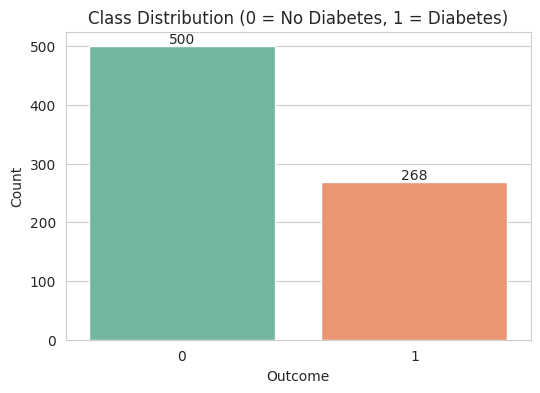

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [39]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Outcome', hue='Outcome', data=df, palette='Set2', legend=False)
plt.title('Class Distribution (0 = No Diabetes, 1 = Diabetes)')
plt.xlabel('Outcome')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

print(df['Outcome'].value_counts(normalize=True) * 100)

###Feature Distributions

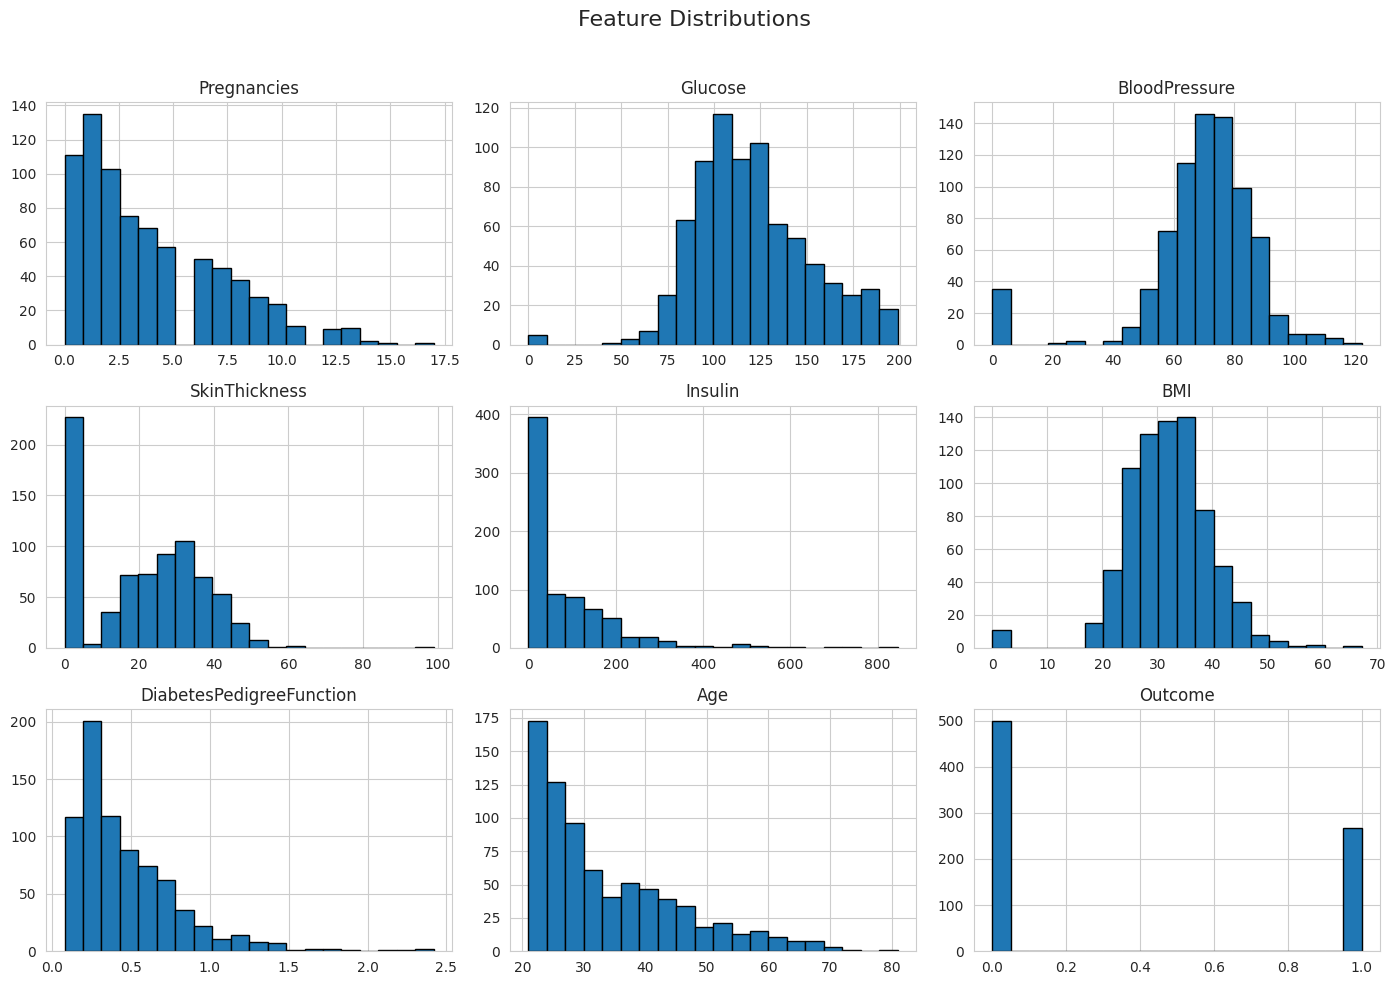

In [40]:
df.hist(figsize=(14, 10), bins=20, edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

###Correlation Heatmap

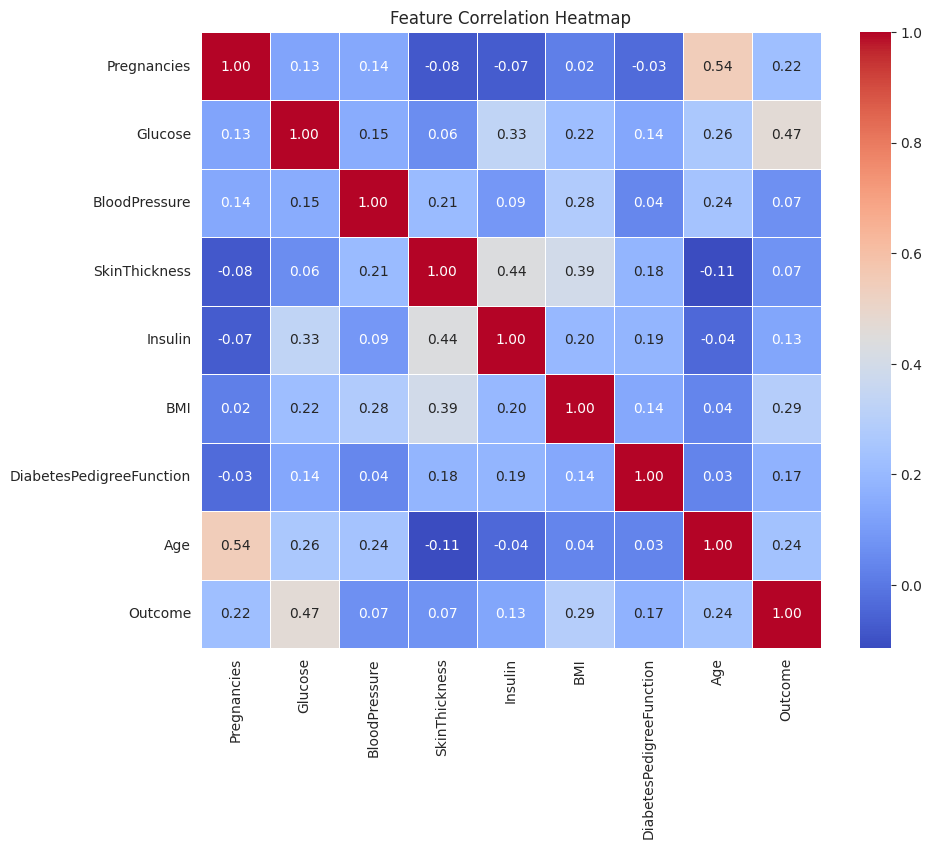

In [41]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

###Bivariate Analysis

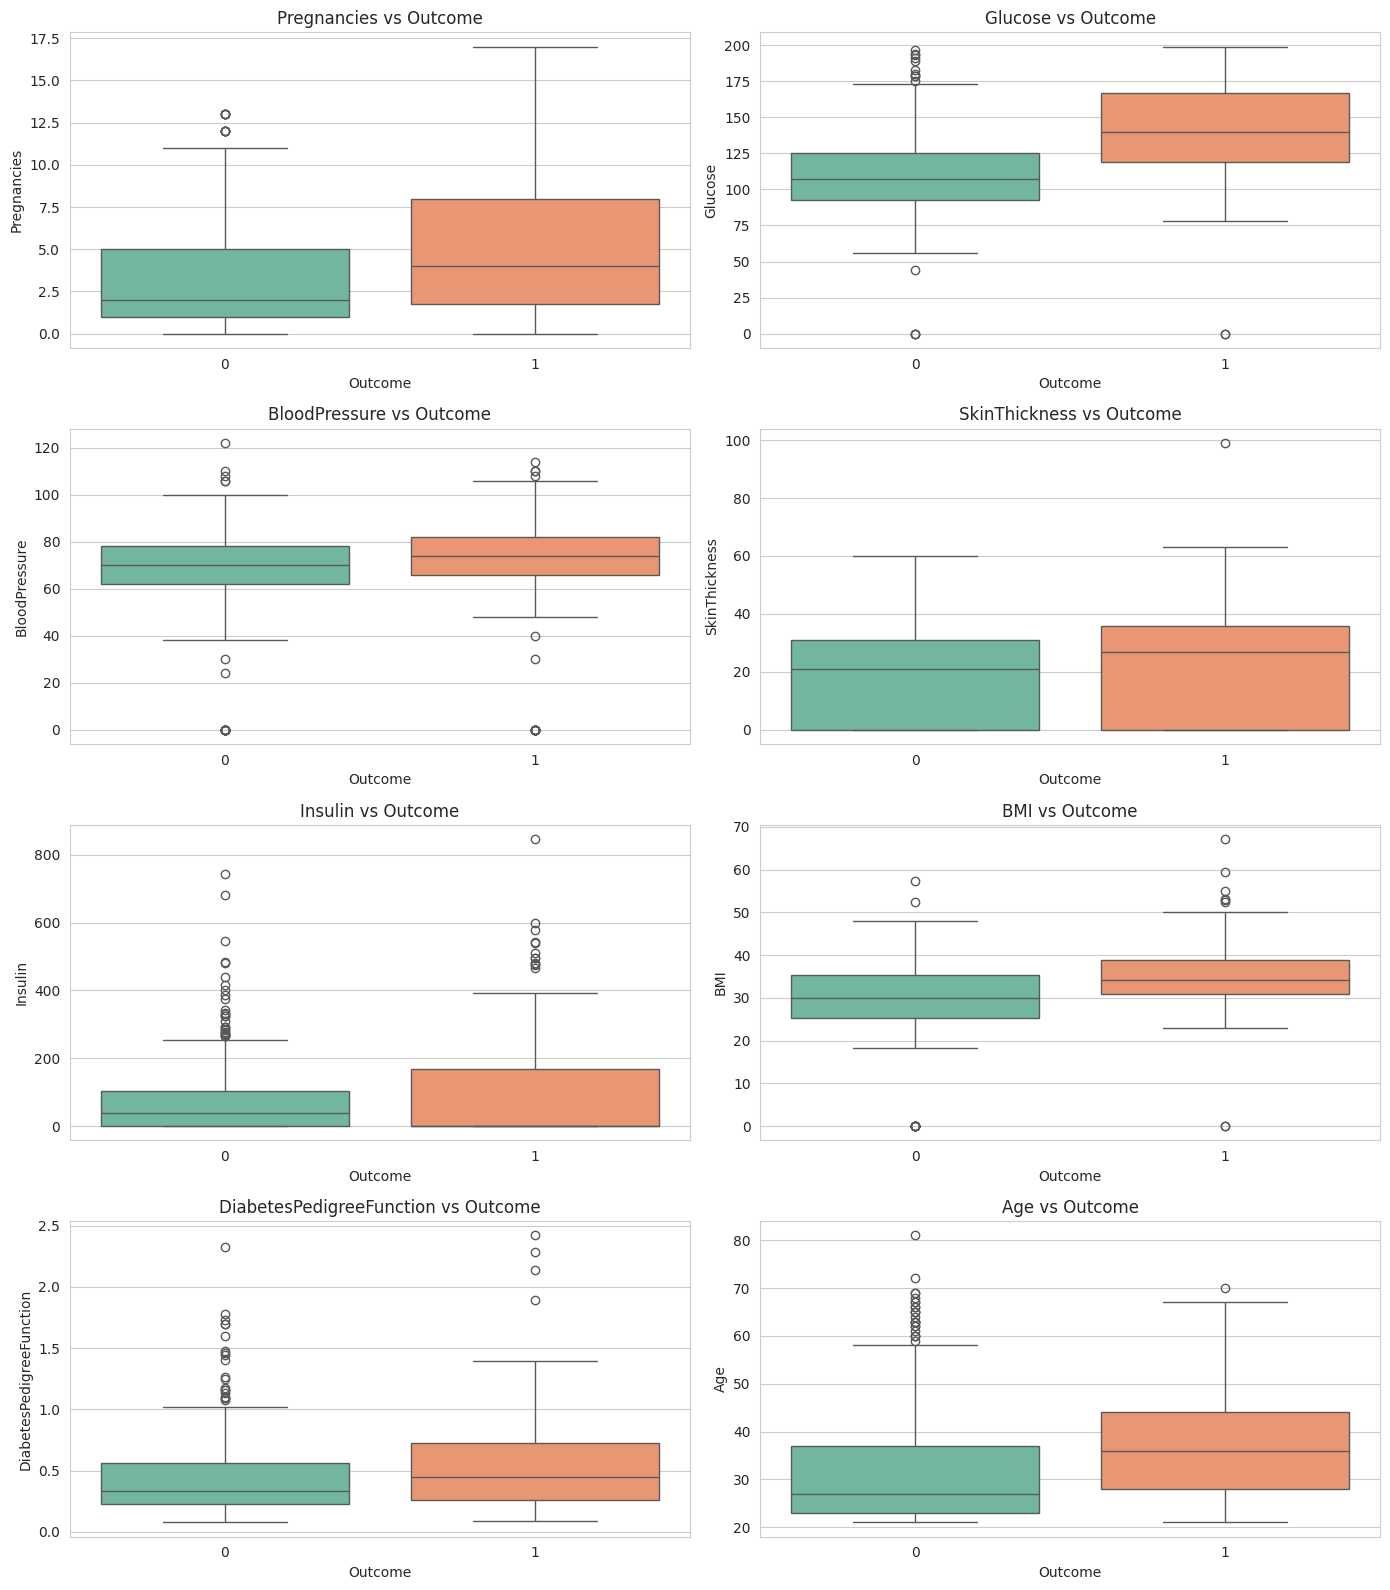

In [42]:
## Bivariate Analysis
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='Outcome', y=col, data=df, ax=axes[i], hue='Outcome',
                palette='Set2', legend=False)
    axes[i].set_title(f'{col} vs Outcome')

plt.tight_layout()
plt.show()

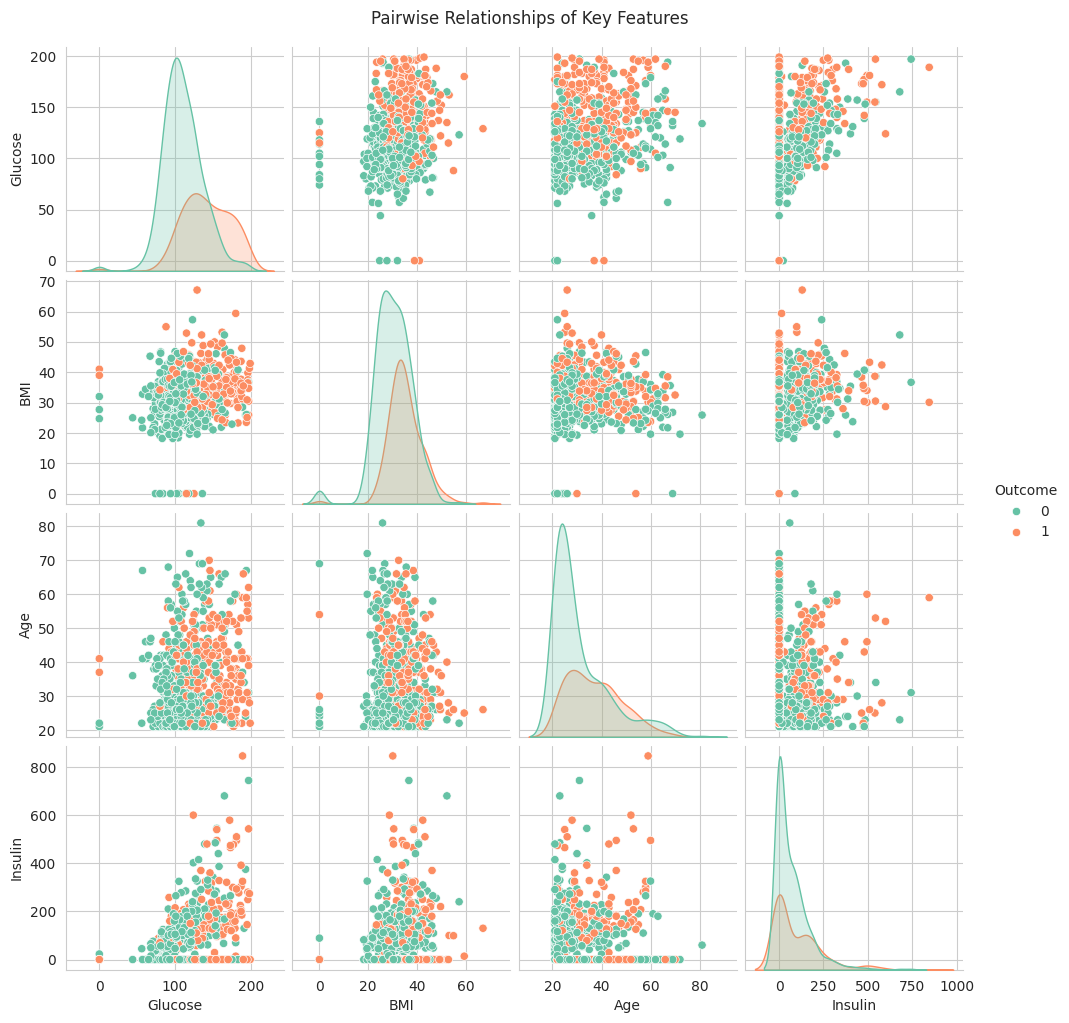

In [43]:
## Pairplot of Key Features
key_features = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
sns.pairplot(df[key_features], hue='Outcome', palette='Set2', diag_kind='kde')
plt.suptitle('Pairwise Relationships of Key Features', y=1.02)
plt.show()

###Outlier Analysis

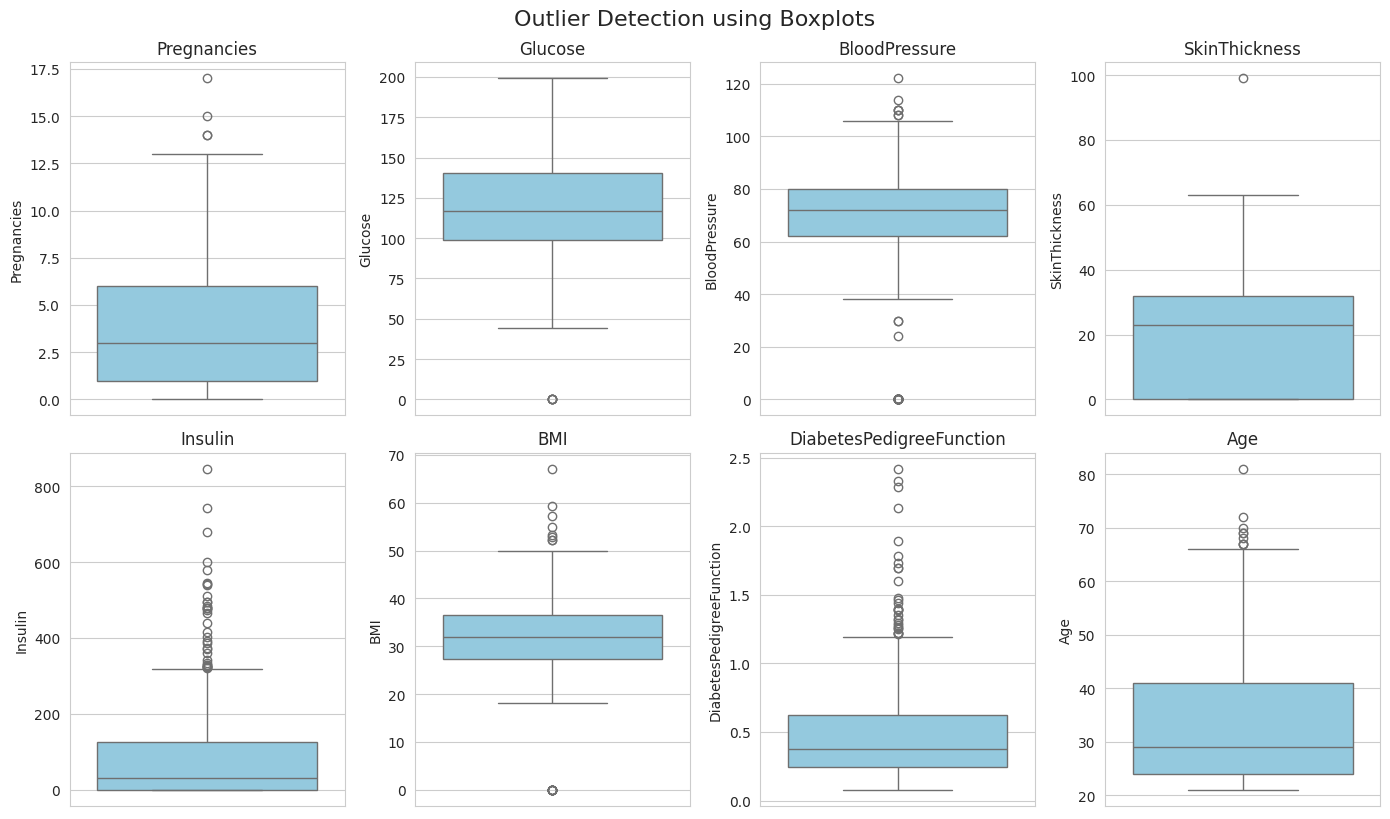

Outlier counts (IQR method):

Pregnancies: 4 outliers
Glucose: 5 outliers
BloodPressure: 45 outliers
SkinThickness: 1 outliers
Insulin: 34 outliers
BMI: 19 outliers
DiabetesPedigreeFunction: 29 outliers
Age: 9 outliers


In [44]:
## Outlier Analysis
plt.figure(figsize=(14, 8))
for i, col in enumerate(features):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.suptitle('Outlier Detection using Boxplots', y=1.02, fontsize=16)
plt.show()

print("Outlier counts (IQR method):\n")
for col in features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

###Fix Hidden Missing Values

In [45]:
cols_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy()
df_clean[cols_with_invalid_zeros] = df_clean[cols_with_invalid_zeros].replace(0, np.nan)

print("Missing values after replacing 0s:")
print(df_clean[cols_with_invalid_zeros].isnull().sum())

Missing values after replacing 0s:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


###Impute Missing Values (Median)

In [46]:
for col in cols_with_invalid_zeros:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

df_clean.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


###Feature/Target Split

In [47]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


###Train/Test Split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (614, 8)
Test shape: (154, 8)


###Feature Scaling

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###Baseline Classification Models

In [50]:
## Baseline Models for Comparison
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

baseline_results = {}

for name, clf in baseline_models.items():
    clf.fit(X_train_scaled, y_train)
    preds = clf.predict(X_test_scaled)

    baseline_results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-score": f1_score(y_test, preds)
    }

    print(f"--- {name} ---")
    print(classification_report(y_test, preds, zero_division=0))

baseline_df = pd.DataFrame(baseline_results).T
baseline_df

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

--- KNN ---
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154

--- SVM ---
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.7

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.707792,0.600000,0.500000,0.545455
KNN,0.753247,0.660000,0.611111,0.634615
SVM,0.740260,0.652174,0.555556,0.600000
Random Forest,0.740260,0.652174,0.555556,0.600000


###Build the MLP

In [51]:
keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_67 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

###Compile

In [52]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

###Compute Class Weights

In [53]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.7675), 1: np.float64(1.4345794392523366)}


###Train

In [54]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.5927 - loss: 0.6667 - val_accuracy: 0.6585 - val_loss: 0.6518
Epoch 2/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6354 - loss: 0.6542 - val_accuracy: 0.6504 - val_loss: 0.6226
Epoch 3/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6640 - loss: 0.6250 - val_accuracy: 0.6911 - val_loss: 0.5917
Epoch 4/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7332 - loss: 0.5911 - val_accuracy: 0.7236 - val_loss: 0.5552
Epoch 5/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7291 - loss: 0.5657 - val_accuracy: 0.7317 - val_loss: 0.5198
Epoch 6/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7373 - loss: 0.5540 - val_accuracy: 0.7561 - val_loss: 0.4955
Epoch 7/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7413 - loss: 0.5341 - val_accuracy: 0.7642 - val_loss: 0.4796
Epoch 8/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7556 - loss: 0.5163 - val_accuracy: 0.7

###Plot Training History

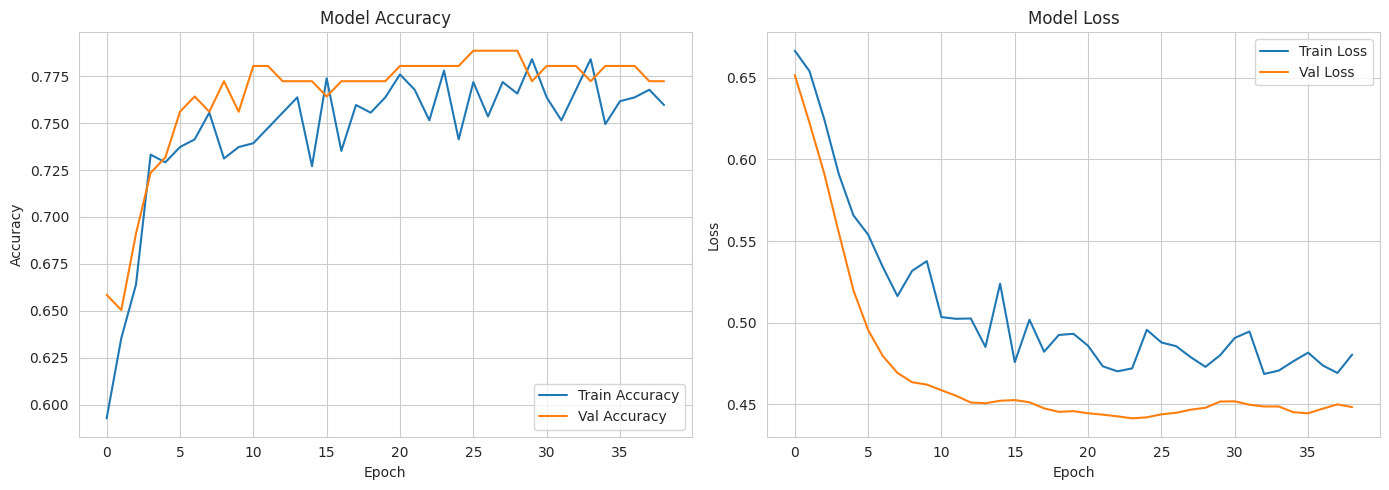

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

###Evaluate on Test Set

In [56]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

Test Accuracy: 0.7468
Test Loss: 0.5490
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.75      0.79       100
           1       0.62      0.74      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.76      0.75      0.75       154



###Confusion Matrix

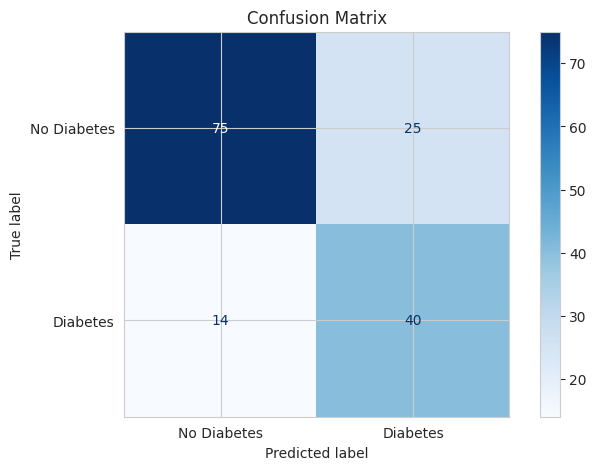

In [57]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

###ROC Curve

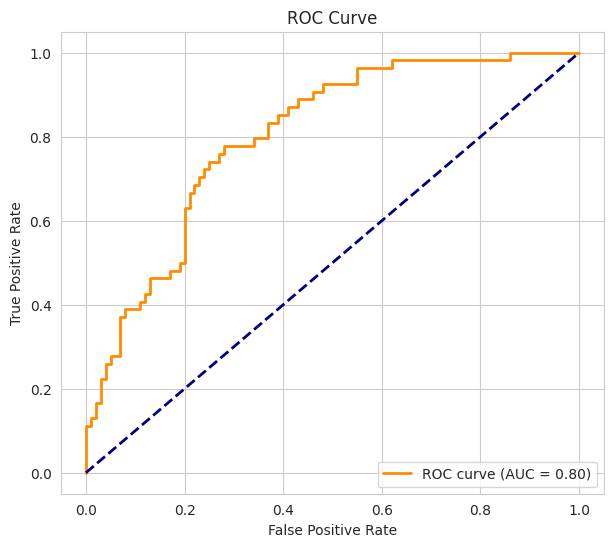

In [58]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

###Precision-Recall Curve

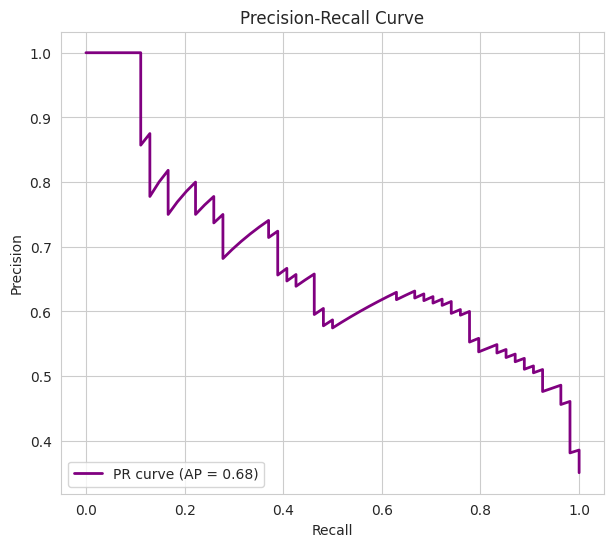

In [59]:
## Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
avg_precision = average_precision_score(y_test, y_pred_prob)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, color='purple', lw=2,
         label=f'PR curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

###Hyperparameter Tuning

In [60]:
## Hyperparameter Tuning for the MLP
import itertools

def build_mlp(hidden_units=(32, 16, 8), dropout_rates=(0.3, 0.2), learning_rate=0.001):
    keras.utils.set_random_seed(42)
    layers_list = [layers.Input(shape=(X_train_scaled.shape[1],))]
    for i, units in enumerate(hidden_units[:-1]):
        layers_list.append(layers.Dense(units, activation='relu'))
        if i < len(dropout_rates):
            layers_list.append(layers.Dropout(dropout_rates[i]))
    layers_list.append(layers.Dense(hidden_units[-1], activation='relu'))
    layers_list.append(layers.Dense(1, activation='sigmoid'))

    m = keras.Sequential(layers_list)
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return m

param_grid = {
    "hidden_units": [(32, 16, 8), (64, 32), (16, 8)],
    "learning_rate": [0.01, 0.001, 0.0005],
    "batch_size": [16, 32]
}

tuning_results = []

for hu, lr, bs in itertools.product(param_grid["hidden_units"],
                                     param_grid["learning_rate"],
                                     param_grid["batch_size"]):
    m_tmp = build_mlp(hidden_units=hu, learning_rate=lr)
    es_tmp = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                            restore_best_weights=True)
    h_tmp = m_tmp.fit(
        X_train_scaled, y_train,
        validation_split=0.2, epochs=100, batch_size=bs,
        callbacks=[es_tmp], class_weight=class_weight_dict, verbose=0
    )
    val_acc = max(h_tmp.history['val_accuracy'])
    tuning_results.append({"hidden_units": hu, "learning_rate": lr,
                            "batch_size": bs, "val_accuracy": val_acc})
    print(f"hidden_units={hu}, lr={lr}, batch_size={bs} -> val_acc={val_acc:.4f}")

tuning_df = pd.DataFrame(tuning_results).sort_values("val_accuracy", ascending=False)
tuning_df.head(10)

hidden_units=(32, 16, 8), lr=0.01, batch_size=16 -> val_acc=0.7886
hidden_units=(32, 16, 8), lr=0.01, batch_size=32 -> val_acc=0.8130
hidden_units=(32, 16, 8), lr=0.001, batch_size=16 -> val_acc=0.7886
hidden_units=(32, 16, 8), lr=0.001, batch_size=32 -> val_acc=0.7805
hidden_units=(32, 16, 8), lr=0.0005, batch_size=16 -> val_acc=0.7886
hidden_units=(32, 16, 8), lr=0.0005, batch_size=32 -> val_acc=0.7805
hidden_units=(64, 32), lr=0.01, batch_size=16 -> val_acc=0.8130
hidden_units=(64, 32), lr=0.01, batch_size=32 -> val_acc=0.8049
hidden_units=(64, 32), lr=0.001, batch_size=16 -> val_acc=0.7886
hidden_units=(64, 32), lr=0.001, batch_size=32 -> val_acc=0.7886
hidden_units=(64, 32), lr=0.0005, batch_size=16 -> val_acc=0.7805
hidden_units=(64, 32), lr=0.0005, batch_size=32 -> val_acc=0.7805
hidden_units=(16, 8), lr=0.01, batch_size=16 -> val_acc=0.8211
hidden_units=(16, 8), lr=0.01, batch_size=32 -> val_acc=0.7967
hidden_units=(16, 8), lr=0.001, batch_size=16 -> val_acc=0.8130
hidden_units

,hidden_units,learning_rate,batch_size,val_accuracy
12,"(16, 8)",0.0100,16,0.821138
1,"(32, 16, 8)",0.0100,32,0.813008
14,"(16, 8)",0.0010,16,0.813008
6,"(64, 32)",0.0100,16,0.813008
16,"(16, 8)",0.0005,16,0.804878
7,"(64, 32)",0.0100,32,0.804878
17,"(16, 8)",0.0005,32,0.796748
13,"(16, 8)",0.0100,32,0.796748
15,"(16, 8)",0.0010,32,0.796748
0,"(32, 16, 8)",0.0100,16,0.788618


###Final Model Training (best hyperparameters)

In [61]:
## Final Model Training (Best Hyperparameters)
best_params = tuning_df.iloc[0]
print("Best hyperparameters found:\n", best_params)

final_model = build_mlp(
    hidden_units=best_params["hidden_units"],
    learning_rate=best_params["learning_rate"]
)

early_stop_final = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

final_history = final_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=int(best_params["batch_size"]),
    callbacks=[early_stop_final],
    class_weight=class_weight_dict,
    verbose=1
)

Best hyperparameters found:
 hidden_units      (16, 8)
learning_rate        0.01
batch_size             16
val_accuracy     0.821138
Name: 12, dtype: object
Epoch 1/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5397 - loss: 0.6673 - val_accuracy: 0.7317 - val_loss: 0.5989
Epoch 2/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7251 - loss: 0.5947 - val_accuracy: 0.7967 - val_loss: 0.5591
Epoch 3/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7556 - loss: 0.5692 - val_accuracy: 0.8130 - val_loss: 0.4818
Epoch 4/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7719 - loss: 0.5215 - val_accuracy: 0.8211 - val_loss: 0.4297
Epoch 5/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7821 - loss: 0.5099 - val_accuracy: 0.7967 - val_loss: 0.4279
Epoch 6/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7739 - loss: 0.4815 - val_accuracy: 0.8049 - val_loss: 0.4286
Epoch 7/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7760 - loss: 0.

###Final Model Evaluation

Final Test Accuracy: 0.7143
Final Test Loss: 0.5326
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Final Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.71      0.76       100
           1       0.57      0.72      0.64        54

    accuracy                           0.71       154
   macro avg       0.70      0.72      0.70       154
weighted avg       0.74      0.71      0.72       154



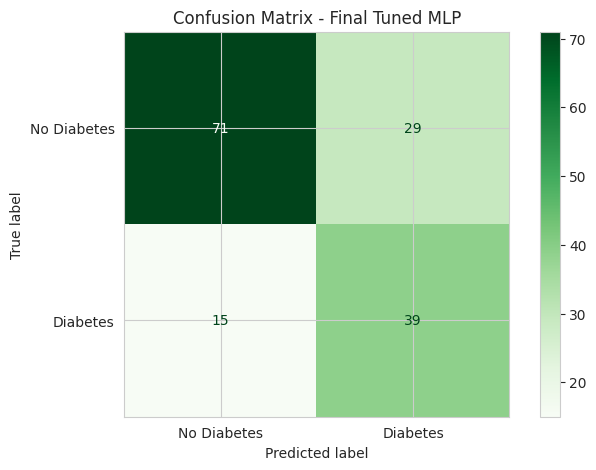

In [62]:
## Final Model Evaluation
test_loss_final, test_acc_final = final_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Final Test Accuracy: {test_acc_final:.4f}")
print(f"Final Test Loss: {test_loss_final:.4f}")

y_pred_prob_final = final_model.predict(X_test_scaled)
y_pred_final = (y_pred_prob_final > 0.5).astype(int)

print("\nFinal Classification Report:\n")
print(classification_report(y_test, y_pred_final, zero_division=0))

cm_final = confusion_matrix(y_test, y_pred_final)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final,
                                     display_labels=['No Diabetes', 'Diabetes'])
disp_final.plot(cmap='Greens', values_format='d')
plt.title('Confusion Matrix - Final Tuned MLP')
plt.show()

###Compare All Models

In [63]:
## Compare All Models
mlp_baseline_results = {
    "Accuracy": test_acc,
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred)
}

mlp_tuned_results = {
    "Accuracy": test_acc_final,
    "Precision": precision_score(y_test, y_pred_final),
    "Recall": recall_score(y_test, y_pred_final),
    "F1-score": f1_score(y_test, y_pred_final)
}

comparison_df = baseline_df.copy()
comparison_df.loc["MLP (Baseline)"] = mlp_baseline_results
comparison_df.loc["MLP (Tuned)"] = mlp_tuned_results
comparison_df = comparison_df.round(4)
comparison_df

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.7078,0.6000,0.5000,0.5455
KNN,0.7532,0.6600,0.6111,0.6346
SVM,0.7403,0.6522,0.5556,0.6000
Random Forest,0.7403,0.6522,0.5556,0.6000
MLP (Baseline),0.7468,0.6154,0.7407,0.6723
MLP (Tuned),0.7143,0.5735,0.7222,0.6393


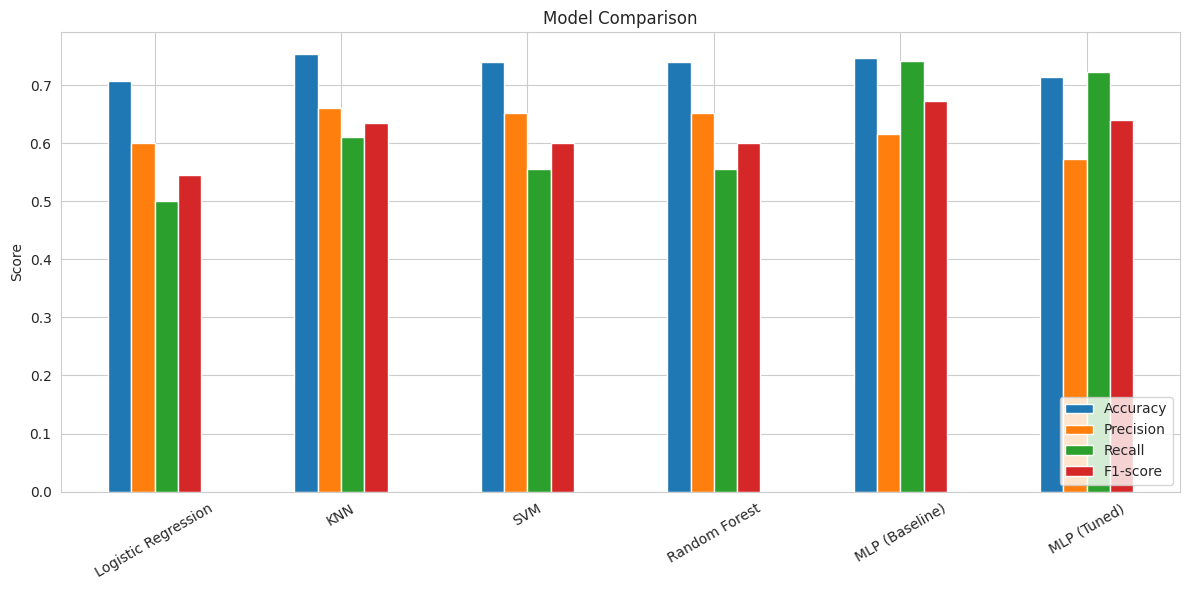

In [64]:
comparison_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [65]:
## Select the Best Model for Deployment
candidates = {
    "Baseline MLP": (model, test_acc, f1_score(y_test, y_pred), recall_score(y_test, y_pred)),
    "Tuned MLP":    (final_model, test_acc_final, f1_score(y_test, y_pred_final), recall_score(y_test, y_pred_final))
}

print(f"{'Model':<15}{'Accuracy':<12}{'F1-score':<12}{'Recall':<10}")
for name, (_, acc, f1, rec) in candidates.items():
    print(f"{name:<15}{acc:<12.4f}{f1:<12.4f}{rec:<10.4f}")

# F1 balances precision & recall — more meaningful than raw accuracy
# for an imbalanced medical dataset where missing a diabetic case matters more
best_name = max(candidates, key=lambda k: candidates[k][2])
deployed_model = candidates[best_name][0]

print(f"\nSelected for deployment: {best_name}")

Model          Accuracy    F1-score    Recall    
Baseline MLP   0.7468      0.6723      0.7407    
Tuned MLP      0.7143      0.6393      0.7222    

Selected for deployment: Baseline MLP


###Save the Model

In [66]:
## Save the Deployed Model
deployed_model.save('diabetes_mlp_model.keras')

import joblib
joblib.dump(scaler, 'scaler.pkl')

print(f"Saved '{best_name}' as diabetes_mlp_model.keras")

Saved 'Baseline MLP' as diabetes_mlp_model.keras
